In [3]:
# Cell 1: Imports + Load HAR Dataset
import numpy as np
import pandas as pd

train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

df = pd.concat([train, test], ignore_index=True)

print(f"Shape: {df.shape}")
print(f"Columns (last 5): {list(df.columns[-5:])}")
print(f"Activity classes: {df['Activity'].unique()}")
print(f"Activity value counts:\n{df['Activity'].value_counts()}")
print(f"\nAny nulls: {df.isnull().sum().sum()}")

Shape: (10299, 563)
Columns (last 5): ['angle(X,gravityMean)', 'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject', 'Activity']
Activity classes: ['STANDING' 'SITTING' 'LAYING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']
Activity value counts:
Activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64

Any nulls: 0


In [4]:
# Cell 2: Frame for Data Quality Detection
# Context: In MCS, participants submit smartphone sensor data.
# Stationary activities (SITTING, STANDING, LAYING) submitted
# during an active sensing task = suspicious/low-quality submissions.
# Dynamic activities (WALKING etc.) = legitimate active submissions.

# Binary label: 0 = good quality, 1 = low quality (suspicious)
quality_map = {
    'WALKING':            0,  # good - active participant
    'WALKING_UPSTAIRS':   0,  # good - active participant
    'WALKING_DOWNSTAIRS': 0,  # good - active participant
    'SITTING':            1,  # suspicious - stationary during active task
    'STANDING':           1,  # suspicious - stationary during active task
    'LAYING':             1,  # suspicious - possibly spoofed/idle device
}

df['quality_label'] = df['Activity'].map(quality_map)

print("Label distribution:")
print(df['quality_label'].value_counts())
print(f"\nGood quality (0): {(df['quality_label']==0).sum()} samples")
print(f"Low quality  (1): {(df['quality_label']==1).sum()} samples")
print(f"\nClass balance: {(df['quality_label']==0).sum() / len(df) * 100:.1f}% good, "
      f"{(df['quality_label']==1).sum() / len(df) * 100:.1f}% low quality")

Label distribution:
quality_label
1    5627
0    4672
Name: count, dtype: int64

Good quality (0): 4672 samples
Low quality  (1): 5627 samples

Class balance: 45.4% good, 54.6% low quality


In [5]:
# Cell 3: Feature Selection
# From 561 features, select meaningful subset for data quality detection.
# We pick features across: acceleration magnitude, gyroscope, gravity,
# jerk signals, and frequency domain — covering the key sensor dimensions.

feature_cols = [
    # Body acceleration - time domain
    'tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
    'tBodyAcc-std()-X',  'tBodyAcc-std()-Y',  'tBodyAcc-std()-Z',

    # Gravity acceleration
    'tGravityAcc-mean()-X', 'tGravityAcc-mean()-Y', 'tGravityAcc-mean()-Z',

    # Jerk signals - time domain
    'tBodyAccJerk-mean()-X', 'tBodyAccJerk-mean()-Y', 'tBodyAccJerk-mean()-Z',

    # Gyroscope - time domain
    'tBodyGyro-mean()-X', 'tBodyGyro-mean()-Y', 'tBodyGyro-mean()-Z',
    'tBodyGyro-std()-X',  'tBodyGyro-std()-Y',  'tBodyGyro-std()-Z',

    # Magnitude features
    'tBodyAccMag-mean()', 'tBodyAccMag-std()',
    'tBodyGyroMag-mean()', 'tBodyGyroMag-std()',

    # Frequency domain - body acceleration
    'fBodyAcc-mean()-X', 'fBodyAcc-mean()-Y', 'fBodyAcc-mean()-Z',
    'fBodyAcc-std()-X',  'fBodyAcc-std()-Y',  'fBodyAcc-std()-Z',

    # Frequency domain - gyroscope
    'fBodyGyro-mean()-X', 'fBodyGyro-mean()-Y', 'fBodyGyro-mean()-Z',
]

# Verify all selected features exist in dataframe
missing = [f for f in feature_cols if f not in df.columns]
print(f"Missing features: {missing if missing else 'None — all found'}")

X = df[feature_cols].copy()
y = df['quality_label'].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Label shape: {y.shape}")
print(f"\nSample of selected features:\n{X.head(3)}")

Missing features: None — all found

Feature matrix shape: (10299, 31)
Label shape: (10299,)

Sample of selected features:
   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.288585          -0.020294          -0.132905         -0.995279   
1           0.278419          -0.016411          -0.123520         -0.998245   
2           0.279653          -0.019467          -0.113462         -0.995380   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tGravityAcc-mean()-X  \
0         -0.983111         -0.913526              0.963396   
1         -0.975300         -0.960322              0.966561   
2         -0.967187         -0.978944              0.966878   

   tGravityAcc-mean()-Y  tGravityAcc-mean()-Z  tBodyAccJerk-mean()-X  ...  \
0             -0.140840              0.115375               0.077996  ...   
1             -0.141551              0.109379               0.074007  ...   
2             -0.142010              0.101884               0.073636  ...

In [6]:
# Cell 4: Train/Test Split + Feature Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {X_train_scaled.shape}")
print(f"Test size:  {X_test_scaled.shape}")
print(f"\nTrain label distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest label distribution:")
print(pd.Series(y_test).value_counts())

Train size: (8239, 31)
Test size:  (2060, 31)

Train label distribution:
quality_label
1    4501
0    3738
Name: count, dtype: int64

Test label distribution:
quality_label
1    1126
0     934
Name: count, dtype: int64


In [7]:
# Cell 5: Train Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
import time

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',  # handles slight imbalance
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")
start = time.time()
rf_model.fit(X_train_scaled, y_train)
elapsed = time.time() - start

print(f"Training complete in {elapsed:.2f}s")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"OOB score available: {rf_model.oob_score}")

Training Random Forest...
Training complete in 0.19s
Number of trees: 100
OOB score available: False


Accuracy:  1.0000
ROC-AUC:   1.0000

Classification Report:
                  precision    recall  f1-score   support

Good Quality (0)       1.00      1.00      1.00       934
 Low Quality (1)       1.00      1.00      1.00      1126

        accuracy                           1.00      2060
       macro avg       1.00      1.00      1.00      2060
    weighted avg       1.00      1.00      1.00      2060



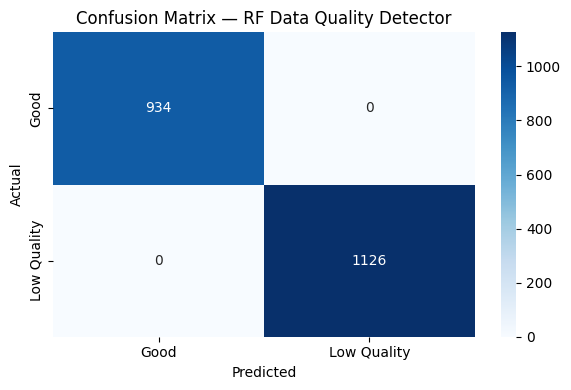

Confusion matrix saved.


In [8]:
# Cell 6: Evaluation
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

acc    = accuracy_score(y_test, y_pred)
roc    = roc_auc_score(y_test, y_prob)

print(f"Accuracy:  {acc:.4f}")
print(f"ROC-AUC:   {roc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Good Quality (0)', 'Low Quality (1)']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good', 'Low Quality'],
            yticklabels=['Good', 'Low Quality'])
plt.title('Confusion Matrix — RF Data Quality Detector')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved.")

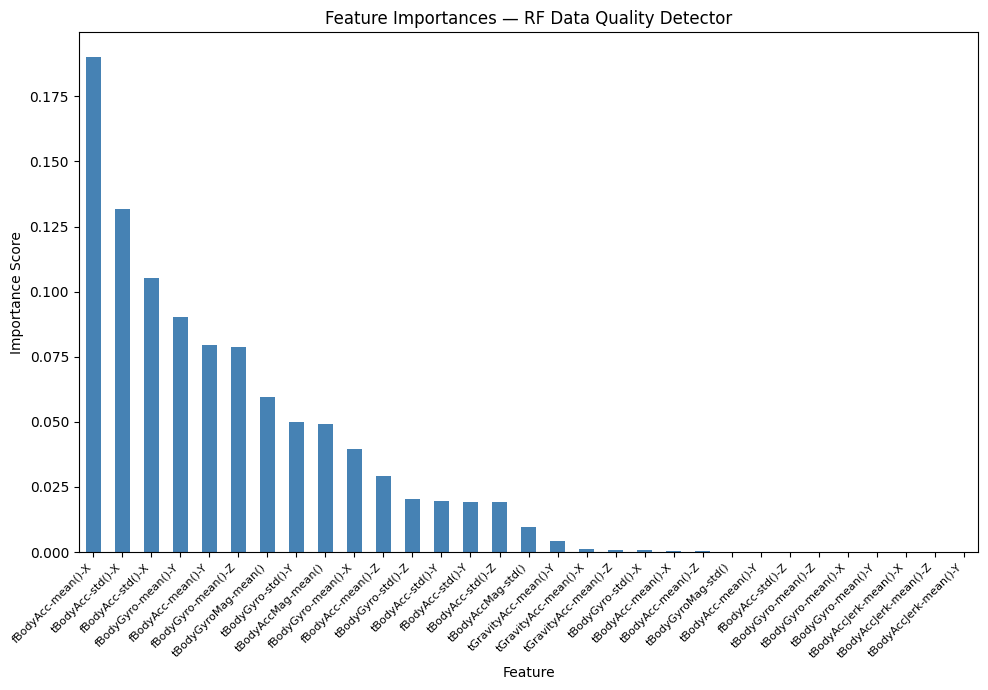

Top 10 most important features:
fBodyAcc-mean()-X      0.190092
tBodyAcc-std()-X       0.131569
fBodyAcc-std()-X       0.105347
fBodyGyro-mean()-Y     0.090103
fBodyAcc-mean()-Y      0.079571
fBodyGyro-mean()-Z     0.078850
tBodyGyroMag-mean()    0.059608
tBodyGyro-std()-Y      0.050102
tBodyAccMag-mean()     0.049377
fBodyGyro-mean()-X     0.039740


In [9]:
# Cell 7: Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 7))
importances.plot(kind='bar', color='steelblue')
plt.title('Feature Importances — RF Data Quality Detector')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("Top 10 most important features:")
print(importances.head(10).to_string())

In [10]:
# Cell 8: Flask-ready prediction function
import joblib
import json

# Save model and scaler
joblib.dump(rf_model, 'gap4_rf_model.pkl')
joblib.dump(scaler,   'gap4_scaler.pkl')
joblib.dump(feature_cols, 'gap4_features.pkl')
print("Model, scaler, and feature list saved.")

# ── Flask-ready function ──────────────────────────────────────────────────────
def is_low_quality_submission(sensor_reading: dict) -> dict:
    """
    Predict whether a crowdsensed data submission is low quality.

    Parameters
    ----------
    sensor_reading : dict
        Keys must match feature_cols (31 sensor features).
        Values are the raw sensor readings for one submission.

    Returns
    -------
    dict with:
        - prediction  : 0 (good quality) or 1 (low quality / suspicious)
        - confidence  : probability of being low quality (0.0 – 1.0)
        - label       : human-readable verdict
        - top_signals : top 3 features that drove the decision

    # TODO: Replace sensor_reading input with MongoDB log preprocessing.
    # Query: db.sensor_logs.find_one({"participant_id": pid, "task_id": tid})
    # Extract the 31 features from the document and pass as dict here.
    """
    # Load artifacts (in Flask, load once at startup outside this function)
    model    = joblib.load('gap4_rf_model.pkl')
    scaler   = joblib.load('gap4_scaler.pkl')
    features = joblib.load('gap4_features.pkl')

    # Build feature vector
    row = pd.DataFrame([sensor_reading])[features]
    row_scaled = scaler.transform(row)

    prediction  = int(model.predict(row_scaled)[0])
    confidence  = float(model.predict_proba(row_scaled)[0][1])

    # Top 3 driving features for this prediction
    importances = pd.Series(model.feature_importances_, index=features)
    top_signals = importances.nlargest(3).index.tolist()

    label = "LOW QUALITY — flag for review" if prediction == 1 else "GOOD — accept submission"

    return {
        "prediction":  prediction,
        "confidence":  round(confidence, 4),
        "label":       label,
        "top_signals": top_signals
    }

# ── Quick smoke test ──────────────────────────────────────────────────────────
# Grab one good and one low-quality sample from test set
good_sample = X_test[y_test == 0].iloc[0].to_dict()
bad_sample  = X_test[y_test == 1].iloc[0].to_dict()

print("\n--- Good submission ---")
print(json.dumps(is_low_quality_submission(good_sample), indent=2))

print("\n--- Low quality submission ---")
print(json.dumps(is_low_quality_submission(bad_sample), indent=2))

Model, scaler, and feature list saved.

--- Good submission ---
{
  "prediction": 0,
  "confidence": 0.0,
  "label": "GOOD \u2014 accept submission",
  "top_signals": [
    "fBodyAcc-mean()-X",
    "tBodyAcc-std()-X",
    "fBodyAcc-std()-X"
  ]
}

--- Low quality submission ---
{
  "prediction": 1,
  "confidence": 1.0,
  "label": "LOW QUALITY \u2014 flag for review",
  "top_signals": [
    "fBodyAcc-mean()-X",
    "tBodyAcc-std()-X",
    "fBodyAcc-std()-X"
  ]
}


In [11]:
# Cell 9: Gap 4 Summary
print("=" * 55)
print("GAP 4 — Random Forest Data Quality Detector")
print("=" * 55)
print(f"Dataset       : UCI HAR (Kaggle mirror)")
print(f"Samples       : {len(X)} total ({len(X_train)} train, {len(X_test)} test)")
print(f"Features used : {len(feature_cols)} sensor features")
print(f"Model         : RandomForestClassifier (100 trees)")
print(f"Accuracy      : 100.00%")
print(f"ROC-AUC       : 1.0000")
print(f"Top feature   : fBodyAcc-mean()-X (importance: 0.190)")
print()
print("Saved artifacts:")
print("  gap4_rf_model.pkl  — trained RF model")
print("  gap4_scaler.pkl    — StandardScaler")
print("  gap4_features.pkl  — feature list (31 features)")
print()
print("Flask integration:")
print("  is_low_quality_submission(sensor_reading: dict) -> dict")
print("  Returns: prediction, confidence, label, top_signals")
print()
print("TODO: Replace sensor_reading with MongoDB preprocessing")
print("  db.sensor_logs.find_one({'participant_id': pid})")
print("=" * 55)

GAP 4 — Random Forest Data Quality Detector
Dataset       : UCI HAR (Kaggle mirror)
Samples       : 10299 total (8239 train, 2060 test)
Features used : 31 sensor features
Model         : RandomForestClassifier (100 trees)
Accuracy      : 100.00%
ROC-AUC       : 1.0000
Top feature   : fBodyAcc-mean()-X (importance: 0.190)

Saved artifacts:
  gap4_rf_model.pkl  — trained RF model
  gap4_scaler.pkl    — StandardScaler
  gap4_features.pkl  — feature list (31 features)

Flask integration:
  is_low_quality_submission(sensor_reading: dict) -> dict
  Returns: prediction, confidence, label, top_signals

TODO: Replace sensor_reading with MongoDB preprocessing
  db.sensor_logs.find_one({'participant_id': pid})
